# Deep Learning 2 — Como a rede aprende

Link Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ftl-brazil-2026/ebook/blob/main/ml-dl/dl2_como_a_rede_aprende.ipynb)

Na aula 1 vimos que uma rede neural é uma função com muitos parâmetros (101.770 no nosso MLP do MNIST) e que,
com pesos aleatórios, ela chuta ~10% para cada dígito. Hoje vamos ver **como os pesos são ajustados**.

O ciclo do aprendizado tem três peças:

1. **Função de perda** (*loss*): um número que mede o quanto a rede está errando
2. **Gradiente**: em que direção mexer cada peso para a perda diminuir (calculado pela **retropropagação**)
3. **Atualização**: dar um pequeno passo nessa direção (**descida do gradiente**)

Repetindo esse ciclo milhares de vezes, a rede aprende.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


AZUL, LARANJA, VERDE, CINZA, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#898781", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": CINZA, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "figure.dpi": 110,
})

torch.manual_seed(42)
np.set_printoptions(precision=3, suppress=True)

# o mesmo MNIST e o mesmo MLP da aula 1
treino = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
teste = datasets.MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())

def cria_mlp():
    return nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))

modelo = cria_mlp()

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.94MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 206kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.15MB/s]


## 1. Funções de perda (Loss)

A **perda** compara a previsão $\hat{y}$ com o valor verdadeiro $y$ e devolve **um único número**: quanto
menor, melhor. Treinar a rede é procurar os pesos que deixam a perda mínima.

### Regressão: erro quadrático médio (MSE)

Quando a saída é um número contínuo (temperatura, chuva, preço):

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

Elevar ao quadrado deixa todo erro positivo e pune muito mais os erros grandes.

In [2]:
y_real = torch.tensor([2.0, 3.5, 1.0])
y_prev = torch.tensor([2.5, 3.0, 2.0])

erros = y_prev - y_real
print(f"erros:            {erros.tolist()}")
print(f"erros ao quadrado: {(erros ** 2).tolist()}")
print(f"MSE à mão:   {(erros ** 2).mean():.4f}")
print(f"nn.MSELoss:  {nn.MSELoss()(y_prev, y_real):.4f}")

erros:            [0.5, -0.5, 1.0]
erros ao quadrado: [0.25, 0.25, 1.0]
MSE à mão:   0.5000
nn.MSELoss:  0.5000


### Classificação: entropia cruzada (*cross-entropy*)

Vimos na aula anterior, que com o MNIST dataset, e a nossa MLP, a rede devolve 10 *logits*, que logo na saída a softmax transforma em probabilidades. 

Assim, a entropia cruzada olha só para a probabilidade que a rede deu à **classe correta**, $p_{\text{correta}}$:

$$\text{CE} = -\log(p_{\text{correta}})$$

- Se a rede dá 100% para a classe certa: $-\log(1) = 0$, perda zero.
- Se dá quase 0% para a classe certa: $-\log(0{,}001) \approx 6{,}9$, perda enorme.

Vamos calcular à mão para uma imagem e comparar com o PyTorch. No PyTorch, `F.cross_entropy` recebe os
**logits** diretamente (ele aplica a softmax internamente).

In [3]:
imagem, rotulo = treino[0]
logits = modelo(imagem.unsqueeze(0))            # (1, 10)
probs = torch.softmax(logits, dim=1)

p_correta = probs[0, rotulo]
print(f"rótulo verdadeiro: {rotulo}")
print(f"probabilidade dada ao dígito {rotulo}: {p_correta:.4f}")
print(f"CE à mão:         -log({p_correta:.4f}) = {-torch.log(p_correta):.4f}")
print(f"F.cross_entropy:  {F.cross_entropy(logits, torch.tensor([rotulo])):.4f}")

rótulo verdadeiro: 5
probabilidade dada ao dígito 5: 0.1020
CE à mão:         -log(0.1020) = 2.2828
F.cross_entropy:  2.2828


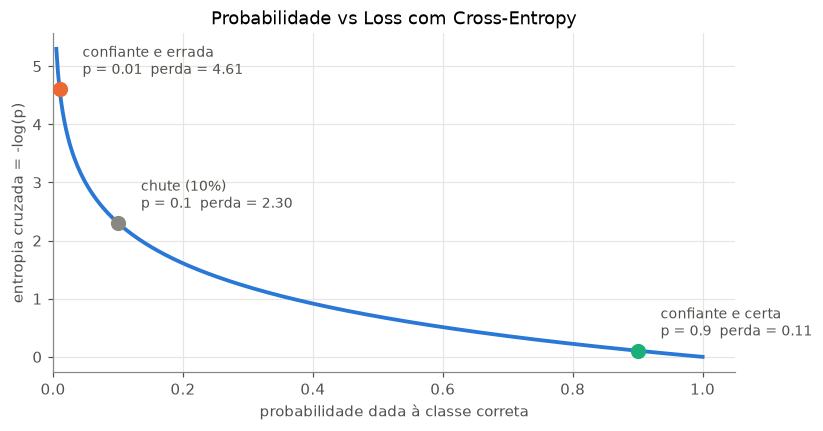

In [5]:
p = np.linspace(0.005, 1, 400)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p, -np.log(p), color=AZUL, lw=2.5)
for valor, texto, cor in [(0.9, "confiante e certa", VERDE), (0.1, "chute (10%)", CINZA), (0.01, "confiante e errada", LARANJA)]:
    ax.scatter(valor, -np.log(valor), s=80, color=cor, zorder=3)
    ax.annotate(f"{texto}\np = {valor}  perda = {-np.log(valor):.2f}", (valor, -np.log(valor)),
                xytext=(15, 10), textcoords="offset points", color=TINTA, fontsize=9)
ax.set(xlabel="probabilidade dada à classe correta", ylabel="entropia cruzada = -log(p)",
       title="Probabilidade vs Loss com Cross-Entropy", xlim=(0, 1.05))
plt.show()

**Teste de sanidade:** uma rede que ainda não aprendeu nada dá ~10% para cada um dos 10 dígitos, então a perda
média deveria ser perto de $-\log(0{,}1) = \ln(10) \approx 2{,}30$. Se a perda inicial de um modelo for muito
diferente disso, alguma coisa está errada no código.

In [6]:
lote_grande = next(iter(DataLoader(treino, batch_size=1000)))
x_lote, y_lote = lote_grande
with torch.no_grad():
    perda_inicial = F.cross_entropy(modelo(x_lote), y_lote)
print(f"perda média da rede não treinada (1000 imagens): {perda_inicial:.3f}")
print(f"ln(10) = {np.log(10):.3f}")

perda média da rede não treinada (1000 imagens): 2.298
ln(10) = 2.303


## Gradient Descent

Imagine a perda como uma paisagem, em que cada combinação de pesos é um ponto, e a altura é a perda. Queremos
chegar ao vale o mais rápido possível. Assim, o **gradiente** $\nabla L$ aponta para onde a perda **sobe** mais rápido. O truque disso, é que vamos apontar no sentido **contrário**:

$$\theta_i \leftarrow \theta - \eta \, \nabla L(\theta)$$

- $\theta$: os parâmetros (pesos e vieses)
- $\eta$ (eta): a **taxa de aprendizado** (*learning rate*), o tamanho do passo

Começamos com um único parâmetro e uma perda simples, $L(\theta) = (\theta - 3)^2$, cujo mínimo está em
$\theta = 3$ e cujo gradiente é $\nabla L = 2(\theta - 3)$.

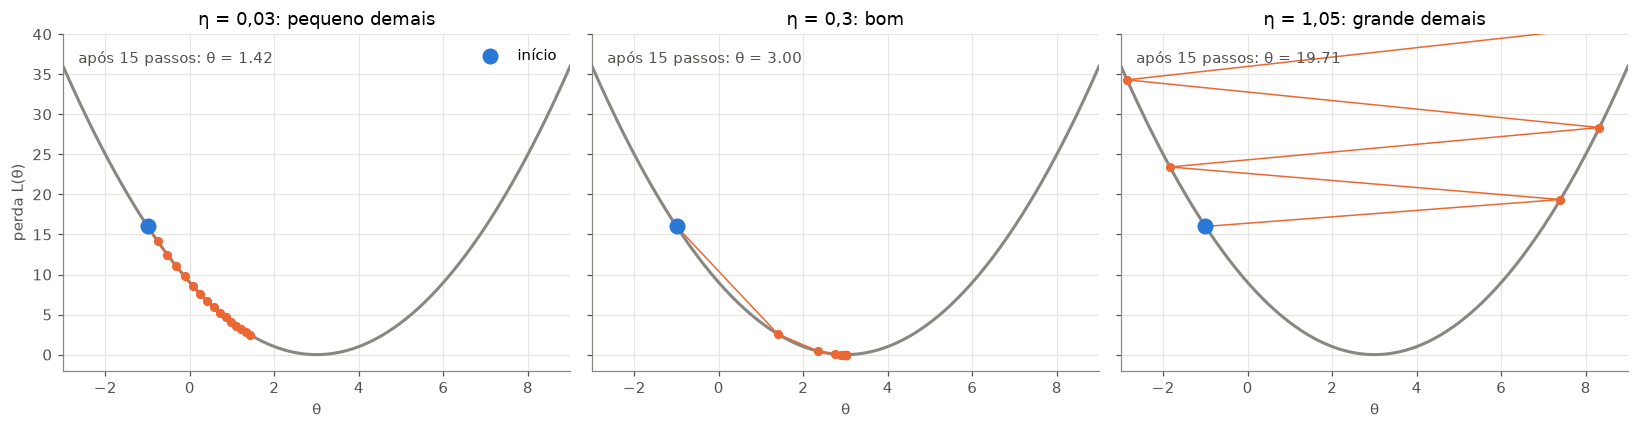

In [6]:
def perda_1d(theta):
    return (theta - 3) ** 2

def gradiente_1d(theta):
    return 2 * (theta - 3)

def descida_1d(theta0, eta, passos=15):
    caminho = [theta0]
    for _ in range(passos):
        caminho.append(caminho[-1] - eta * gradiente_1d(caminho[-1]))
    return np.array(caminho)

thetas = np.linspace(-3, 9, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (eta, titulo) in zip(axes, [(0.03, "η = 0,03: pequeno demais"), (0.3, "η = 0,3: bom"), (1.05, "η = 1,05: grande demais")]):
    caminho = descida_1d(theta0=-1.0, eta=eta)
    ax.plot(thetas, perda_1d(thetas), color=CINZA, lw=2)
    ax.plot(caminho, perda_1d(caminho), color=LARANJA, lw=1, marker="o", ms=5)
    ax.scatter(caminho[0], perda_1d(caminho[0]), s=90, color=AZUL, zorder=3, label="início")
    ax.set(title=titulo, xlabel="θ", ylim=(-2, 40), xlim=(-3, 9))
    ax.text(0.03, 0.95, f"após 15 passos: θ = {caminho[-1]:.2f}", transform=ax.transAxes, va="top", color=TINTA)
axes[0].set_ylabel("perda L(θ)")
axes[0].legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

- **η pequeno demais:** chega lá, mas devagar (muitos passos = muito tempo de treino).
- **η bom:** chega rápido ao mínimo $\theta = 3$.
- **η grande demais:** cada passo **passa do ponto** e cai mais longe do outro lado: a perda explode
  (*divergência*).

### Em duas dimensões

Uma rede de verdade tem milhares de parâmetros, mas a ideia é a mesma. Com 2 parâmetros dá para desenhar a
paisagem como um mapa de curvas de nível. Usamos $L(\theta_1, \theta_2) = \theta_1^2 + 25\,\theta_2^2$, um
vale **alongado**: muito íngreme na direção $\theta_2$ e quase plano na direção $\theta_1$. Paisagens assim são
comuns em redes neurais.

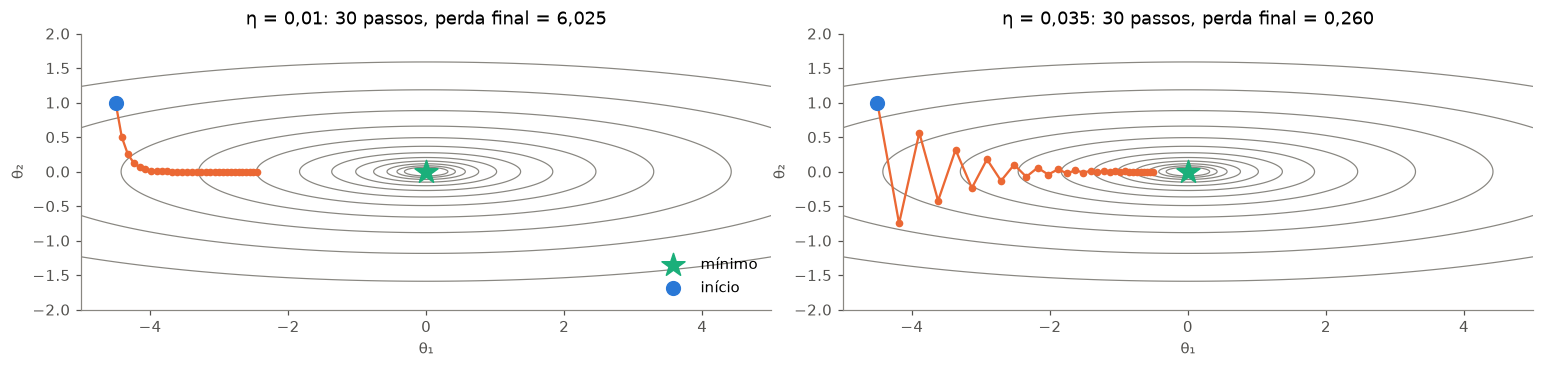

In [7]:
def perda_2d(t1, t2):
    return t1 ** 2 + 25 * t2 ** 2

def gradiente_2d(t1, t2):
    return np.array([2 * t1, 50 * t2])

def descida_2d(inicio, eta, passos=30):
    caminho = [np.array(inicio, dtype=float)]
    for _ in range(passos):
        caminho.append(caminho[-1] - eta * gradiente_2d(*caminho[-1]))
    return np.array(caminho)

T1, T2 = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-2, 2, 300))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, eta in zip(axes, [0.01, 0.035]):
    caminho = descida_2d([-4.5, 1.0], eta)
    ax.contour(T1, T2, perda_2d(T1, T2), levels=np.logspace(-1, 1.8, 12), colors=CINZA, linewidths=0.8)
    ax.plot(caminho[:, 0], caminho[:, 1], color=LARANJA, marker="o", ms=4, lw=1.5)
    ax.scatter(0, 0, marker="*", s=250, color=VERDE, zorder=3, label="mínimo")
    ax.scatter(*caminho[0], s=80, color=AZUL, zorder=3, label="início")
    ax.set(title=f"η = {eta}: 30 passos, perda final = {perda_2d(*caminho[-1]):.3f}".replace(".", ","), xlabel="θ₁", ylabel="θ₂")
    ax.set_aspect("equal")
    ax.grid(False)
axes[0].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

Com η pequeno, o caminho é suave mas não chega ao mínimo em 30 passos. Com η maior, ele anda mais rápido em
$\theta_1$ mas faz **zigue-zague** em $\theta_2$, a direção íngreme. Não existe um η perfeito para as duas
direções ao mesmo tempo. Na aula 3 veremos otimizadores (*momentum*, Adam) que resolvem isso.

## Retropropagação (*backpropagation*): a regra da cadeia, camada por camada

Para usar a descida do gradiente precisamos de $\frac{\partial L}{\partial w}$ para **cada** peso. A
retropropagação calcula isso de forma eficiente usando a **regra da cadeia**: se $L$ depende de $\hat{y}$, que
depende de $h$, que depende de $w$, então

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial h} \cdot \frac{\partial h}{\partial w}$$

Vamos fazer à mão uma rede minúscula, com **só dois pesos**:

$$z = w_1 x \qquad h = \text{ReLU}(z) \qquad \hat{y} = w_2 h \qquad L = (\hat{y} - y)^2$$

com $x = 2$, $y = 1$, $w_1 = 0{,}5$ e $w_2 = 0{,}8$.

In [8]:
x, y = 2.0, 1.0
w1, w2 = 0.5, 0.8

# forward pass: da entrada para a perda
z = w1 * x
h = max(0.0, z)
y_hat = w2 * h
L = (y_hat - y) ** 2
print("FORWARD")
print(f"  z = w1·x = {z:.3f}   h = ReLU(z) = {h:.3f}   ŷ = w2·h = {y_hat:.3f}   L = (ŷ - y)² = {L:.4f}")

# backward pass: da perda para os pesos, multiplicando derivadas locais
dL_dyhat = 2 * (y_hat - y)
dyhat_dw2 = h
dyhat_dh = w2
dh_dz = 1.0 if z > 0 else 0.0          # derivada da ReLU
dz_dw1 = x

dL_dw2 = dL_dyhat * dyhat_dw2
dL_dw1 = dL_dyhat * dyhat_dh * dh_dz * dz_dw1
print("\nBACKWARD (regra da cadeia)")
print(f"  ∂L/∂ŷ = 2(ŷ - y) = {dL_dyhat:.3f}")
print(f"  ∂L/∂w2 = ∂L/∂ŷ · h = {dL_dyhat:.3f} × {dyhat_dw2:.3f} = {dL_dw2:.4f}")
print(f"  ∂L/∂w1 = ∂L/∂ŷ · w2 · ReLU'(z) · x = {dL_dyhat:.3f} × {dyhat_dh:.3f} × {dh_dz:.0f} × {dz_dw1:.0f} = {dL_dw1:.4f}")

FORWARD
  z = w1·x = 1.000   h = ReLU(z) = 1.000   ŷ = w2·h = 0.800   L = (ŷ - y)² = 0.0400

BACKWARD (regra da cadeia)
  ∂L/∂ŷ = 2(ŷ - y) = -0.400
  ∂L/∂w2 = ∂L/∂ŷ · h = -0.400 × 1.000 = -0.4000
  ∂L/∂w1 = ∂L/∂ŷ · w2 · ReLU'(z) · x = -0.400 × 0.800 × 1 × 2 = -0.6400


### O PyTorch faz isso sozinho: *autograd*

Marcando os pesos com `requires_grad=True`, o PyTorch **registra** cada operação do forward pass. Ao chamar
`L.backward()`, ele percorre esse registro de trás para frente aplicando a regra da cadeia, e guarda cada
derivada no atributo `.grad` do peso correspondente. Os números têm que bater com os nossos:

In [ ]:
w1_t = torch.tensor(0.5, requires_grad=True)
w2_t = torch.tensor(0.8, requires_grad=True)

L_t = (w2_t * torch.relu(w1_t * x) - y) ** 2

## aqui ele computa os gradientes de forma automatica
L_t.backward()

print(f"∂L/∂w1: à mão = {dL_dw1:.4f}   autograd = {w1_t.grad:.4f}")
print(f"∂L/∂w2: à mão = {dL_dw2:.4f}   autograd = {w2_t.grad:.4f}")

∂L/∂w1: à mão = -0.6400   autograd = -0.6400
∂L/∂w2: à mão = -0.4000   autograd = -0.4000


Os dois gradientes são **negativos**: aumentar $w_1$ e $w_2$ diminui a perda (a previsão 0,8 está abaixo do
alvo 1,0). Um passo de descida do gradiente com $\eta = 0{,}1$:

In [10]:
eta = 0.1
with torch.no_grad():                        # a atualização em si não deve ser registrada pelo autograd
    w1_t -= eta * w1_t.grad
    w2_t -= eta * w2_t.grad
    L_novo = (w2_t * torch.relu(w1_t * x) - y) ** 2

print(f"novos pesos: w1 = {w1_t:.3f}, w2 = {w2_t:.3f}")
print(f"perda: {L:.4f} → {L_novo:.4f}")

novos pesos: w1 = 0.564, w2 = 0.840
perda: 0.0400 → 0.0028


**Um passo, e a perda caiu de 0,04 para ~0,003.** Isso é o aprendizado inteiro: forward, perda, backward,
atualização. Agora vamos fazer o mesmo com os 101.770 parâmetros do MLP do MNIST.

## Treinando o MLP do MNIST na raça

Primeiro, com apenas um único step, forward, perda e `backward()`. Cada parâmetro da rede ganha um `.grad` com
**exatamente o mesmo formato** do parâmetro.

In [ ]:
torch.manual_seed(0)
modelo = cria_mlp()
loader = DataLoader(treino, 
                    batch_size=64, 
                    shuffle=True)

x_lote, y_lote = next(iter(loader))
perda = F.cross_entropy(modelo(x_lote), y_lote)
perda.backward()

print(f"perda do lote: {perda.item():.3f}\n")
for nome, p in modelo.named_parameters():
    print(f"{nome:<10} parâmetro {str(tuple(p.shape)):<12} gradiente {str(tuple(p.grad.shape)):<12} |grad| médio = {p.grad.abs().mean():.2e}")

perda do lote: 2.302

1.weight   parâmetro (128, 784)   gradiente (128, 784)   |grad| médio = 9.83e-04
1.bias     parâmetro (128,)       gradiente (128,)       |grad| médio = 3.34e-03
3.weight   parâmetro (10, 128)    gradiente (10, 128)    |grad| médio = 4.07e-03
3.bias     parâmetro (10,)        gradiente (10,)        |grad| médio = 2.02e-02


Vimos aqui que os passos fundamentais são:
- Calcular o forward pass
- Computar o loss
- Computar a retropropagação
- Atualizar os parâmetros dos pesos

---
Pronto, isso é exatamente **1 step**.
 

Agora vamos de treino completo, **sem nenhum otimizador pronto**: só a regra $\theta \leftarrow \theta - \eta\nabla L$
aplicada a cada parâmetro. Usamos **mini-lotes** (*mini-batches*) de 64 imagens: em vez de calcular o
gradiente com as 60 mil imagens a cada passo (lento), estimamos com 64 imagens sorteadas. Isso é a **descida do
gradiente estocástica** (SGD).

Dois detalhes importantes:

- a atualização fica dentro de `torch.no_grad()`, para o autograd não registrar a própria atualização;
- depois de atualizar, **zeramos** os gradientes (`p.grad.zero_()`). Na aula 3 veremos o que acontece se esquecermos.

In [15]:
def acuracia(modelo, dataset, n=10000):
    x, y = next(iter(DataLoader(dataset, batch_size=n)))
    with torch.no_grad():
        return (modelo(x).argmax(dim=1) == y).float().mean().item()

torch.manual_seed(0)
modelo = cria_mlp()
lr = 0.1
steps = 600
print(f"acurácia no teste ANTES de treinar: {acuracia(modelo, teste):.1%}")

historico = []
for passo, (x_lote, y_lote) in enumerate(loader):
    if passo == steps:
        break
    perda = F.cross_entropy(modelo(x_lote), y_lote)   # 1. forward + perda
    perda.backward()                                   # 2. backward: calcula todos os .grad
    with torch.no_grad():
        for p in modelo.parameters():                  # 3. atualização: θ ← θ - η·∇L
            p -= lr * p.grad
            p.grad.zero_()                             # 4. zera os gradientes para o próximo passo
    historico.append(perda.item())

print(f"acurácia no teste DEPOIS de {steps} passos: {acuracia(modelo, teste):.1%}")

acurácia no teste ANTES de treinar: 10.4%
acurácia no teste DEPOIS de 600 passos: 91.6%


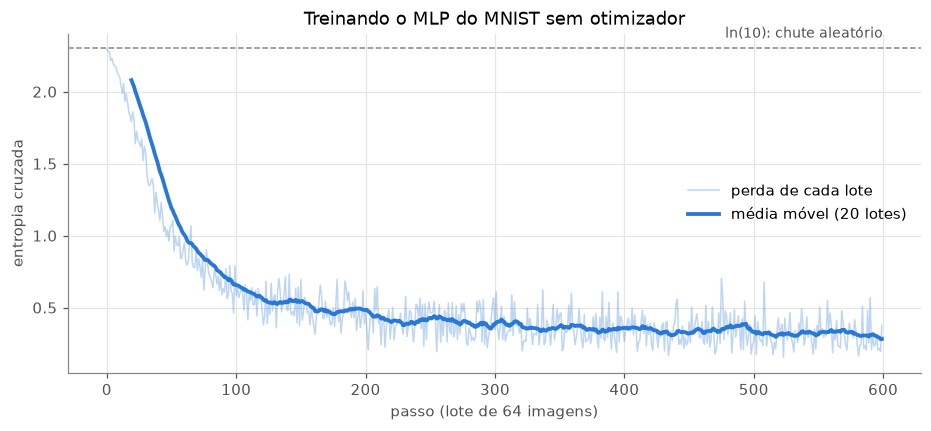

In [16]:
historico = np.array(historico)
media_movel = np.convolve(historico, np.ones(20) / 20, mode="valid")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico, color=AZUL, alpha=0.3, lw=1, label="perda de cada lote")
ax.plot(np.arange(19, len(historico)), media_movel, color=AZUL, lw=2.5, label="média móvel (20 lotes)")
ax.axhline(np.log(10), color=CINZA, ls="--", lw=1)
ax.text(len(historico), np.log(10) + 0.05, "ln(10): chute aleatório", ha="right", va="bottom", color=TINTA, fontsize=9)
ax.set(xlabel="passo (lote de 64 imagens)", ylabel="entropia cruzada", title="Treinando o MLP do MNIST sem otimizador")
ax.legend(frameon=False)
plt.show()

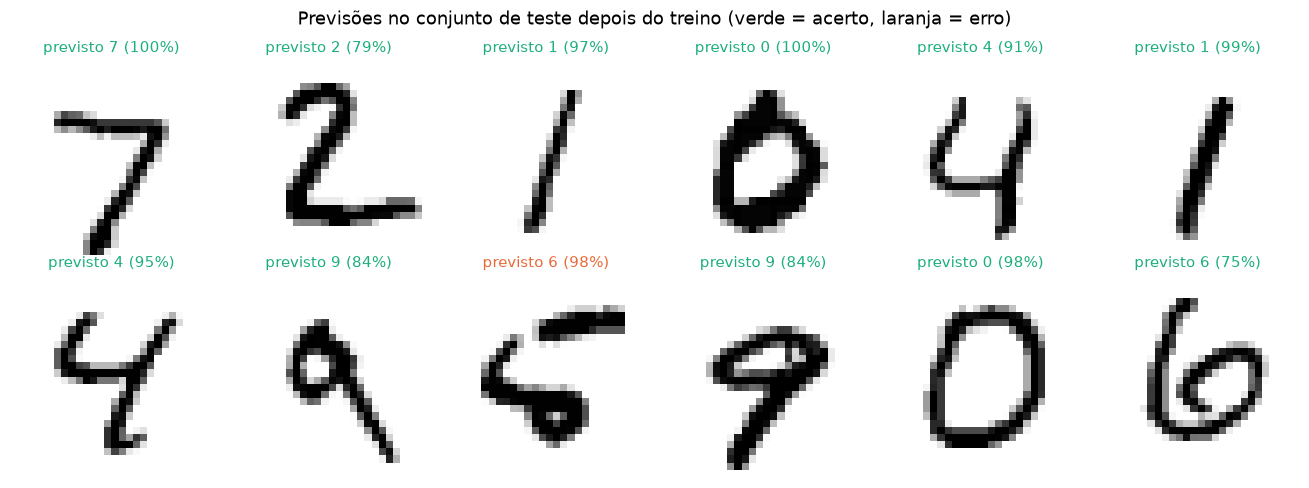

In [17]:
x_ex, y_ex = next(iter(DataLoader(teste, batch_size=12)))
with torch.no_grad():
    probs_ex = torch.softmax(modelo(x_ex), dim=1)

fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
for ax, img, y_true, p in zip(axes.flat, x_ex, y_ex, probs_ex):
    pred = p.argmax().item()
    ax.imshow(img[0], cmap="gray_r")
    ax.set_title(f"previsto {pred} ({p[pred]:.0%})", color=VERDE if pred == y_true else LARANJA, fontsize=10)
    ax.axis("off")
plt.suptitle("Previsões no conjunto de teste depois do treino (verde = acerto, laranja = erro)")
plt.tight_layout()
plt.show()

Em poucos segundos, a rede saiu de ~10% para ~90% de acerto em imagens que **nunca viu**. Não usamos nada além
de: uma perda, `backward()` para os gradientes e a regra de atualização escrita à mão.

## 5. Discussão

- A **perda** transforma "o quanto a rede erra" em um número: MSE para regressão, entropia cruzada para
  classificação. A perda inicial de um classificador de 10 classes deve ser ≈ ln(10) ≈ 2,30.
- A **descida do gradiente** dá passos contra o gradiente: $\theta \leftarrow \theta - \eta\nabla L$. A
  **taxa de aprendizado** η é o hiperparâmetro mais importante: pequena demais é lenta; grande demais diverge.
- A **retropropagação** é a regra da cadeia aplicada da saída para a entrada. O *autograd* do PyTorch faz isso
  com `loss.backward()` e guarda o resultado em `.grad`.
- Usar **mini-lotes** (SGD) torna cada passo barato; a perda de cada lote é ruidosa, mas a tendência cai.

### Exercícios

1. Na seção 3, mude $w_1$ para $-0{,}5$. O que acontece com $\frac{\partial L}{\partial w_1}$? Por quê? (Dica: ReLU.)
2. No treino do MNIST, teste `eta = 0.01` e `eta = 2.0`. Desenhe as três curvas de perda juntas.
3. Comente a linha `p.grad.zero_()` e treine de novo. O que acontece com a perda? Tente explicar antes da aula 3.
4. Calcule à mão a entropia cruzada de uma rede que dá 50% para a classe correta. E 99%?